# Heart Disease Prediction using Machine Learning

## Introduction

Heart disease is a serious medical condition that affects the heart and blood vessels and is one of the main causes of death worldwide. Early detection of heart disease is very important to prevent severe health problems.


## Problem statement
In this project, we use machine learning to analyze patient health data and predict whether a person has heart disease or not. The model helps in identifying high-risk patients at an early stage, which supports better medical decision-making

## Dataset Description

The dataset contains medical details of patients used to predict heart disease. It includes features like age, blood pressure, cholesterol, chest pain type, and other health indicators. The target column shows whether the patient has heart disease (1) or not (0).

## Dataset Size
Rows: 180

Columns: 14

## Dataset Link: 
                https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1016-HeartDieseasePred.zip
                               

## Methodology

Problem Understanding → Data Loading → Data Understanding → Data Cleaning → EDA → Feature Selection → Train-Test Split → Model Building → Model Evaluation → Model Comparison → Best Model Selection → Recommendations → Conclusion

### Import Required Libraries

In [2]:
# Data Loading and Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
#Loading the dataset
df = pd.read_csv("values5.csv")


### Basic Data understanding

In [4]:
#Check first five rows
df.head()

,Patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,Heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [5]:
#chek last five rows
df.tail()


,Patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,Heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [6]:
# Check Dataset Shape
df.shape


(180, 15)

- The dataset contains 180 rows and 14 columns.

In [7]:
# Get Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

The dataset contains numerical and categorical features.
Data types were verified successfully.

In [8]:
# Generate Statistical Summary
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,Heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


- Statistical measures such as mean, minimum, maximum, and standard deviation were analyzed.
- The summary provides an overview of the distribution of numerical features.

#### Target variable check

In [9]:
# Check target variable distribution
df["Heart_disease_present"].value_counts()

Heart_disease_present
0    100
1     80
Name: count, dtype: int64

- The dataset is slightly imbalanced but overall balanced, with 100 negative cases and 80 positive cases.

### Data cleaaning

In [10]:
#Check null values
df.isnull().sum()

Patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
Heart_disease_present                   0
dtype: int64

- No missing values were found in the dataset.

In [11]:
# Check Duplicate Records
df.duplicated().sum()

np.int64(0)

- No duplicate records were found in the dataset.
- The dataset contains unique observations and does not require duplicate removal

In [12]:
# Check Unique Values
df.nunique()

Patient_id                              180
slope_of_peak_exercise_st_segment         3
thal                                      3
resting_blood_pressure                   36
chest_pain_type                           4
num_major_vessels                         4
fasting_blood_sugar_gt_120_mg_per_dl      2
resting_ekg_results                       3
serum_cholesterol_mg_per_dl             118
oldpeak_eq_st_depression                 34
sex                                       2
age                                      40
max_heart_rate_achieved                  73
exercise_induced_angina                   2
Heart_disease_present                     2
dtype: int64

- The dataset consists of binary, categorical, and numerical features.
- patient_id is a unique identifier column for each patient.

In [13]:
# Display Column Names
df.columns

Index(['Patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'Heart_disease_present'],
      dtype='object')

In [14]:

# Drop Patient ID Column
df.drop('Patient_id', axis=1, inplace=True)

The patient_id column was removed because it is a unique identifier and does not contain information relevant to heart disease prediction.

In [15]:
#Recheck the column names
df.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'Heart_disease_present'],
      dtype='object')

## Exploratory Data Analysis 

### Univariate Analysis

#### Numerical Features (Histogram)

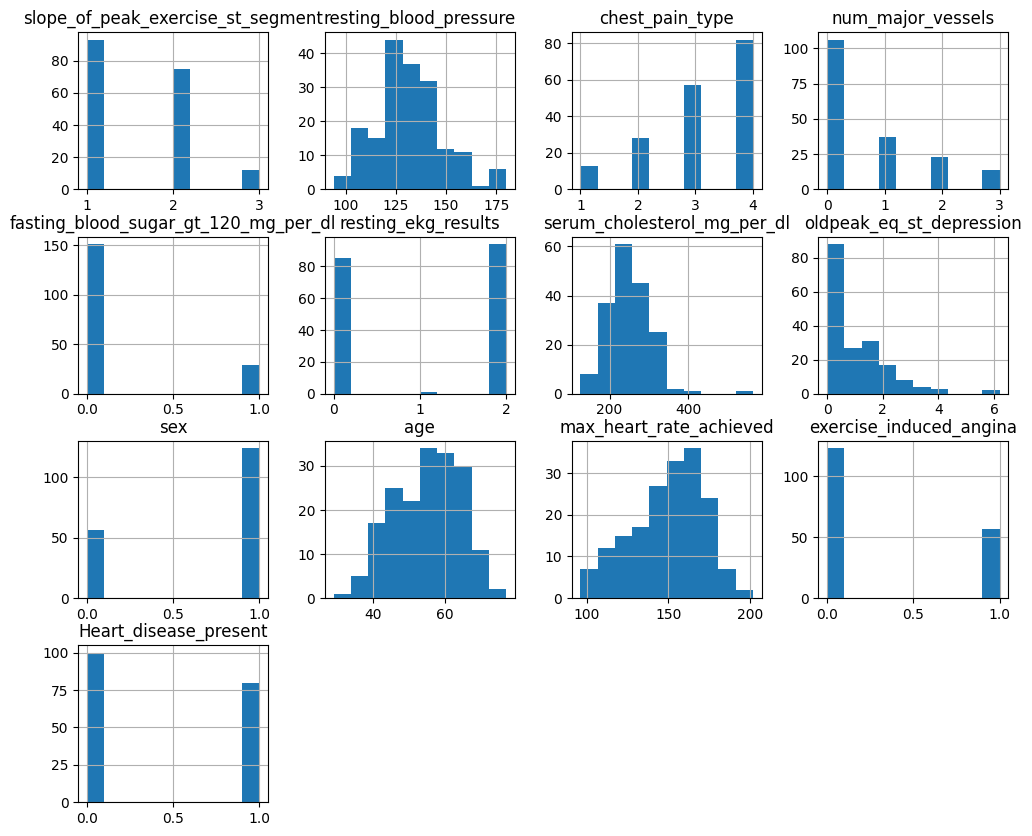

In [16]:
df.hist(figsize=(12,10))
plt.show()

- Histograms were plotted for all 13 numerical features to understand their distributions.
- The plots show the spread and variation of each feature, with some variables appearing slightly skewed while others are more normally distributed.
- This helps in understanding the overall data distribution before model building.

#### Categorical Features (Bar Chart)

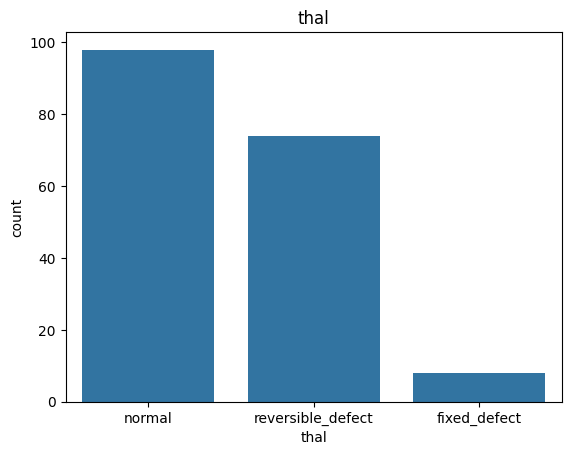

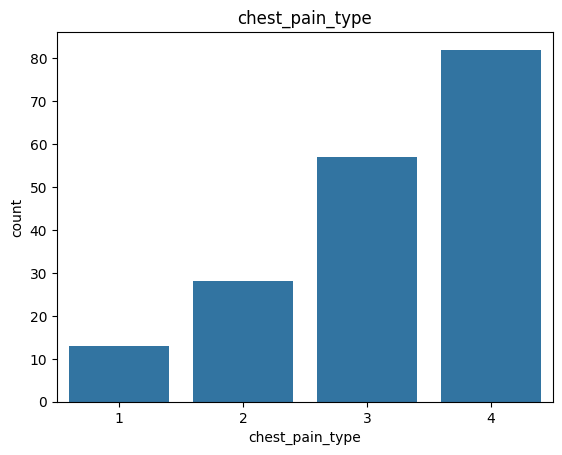

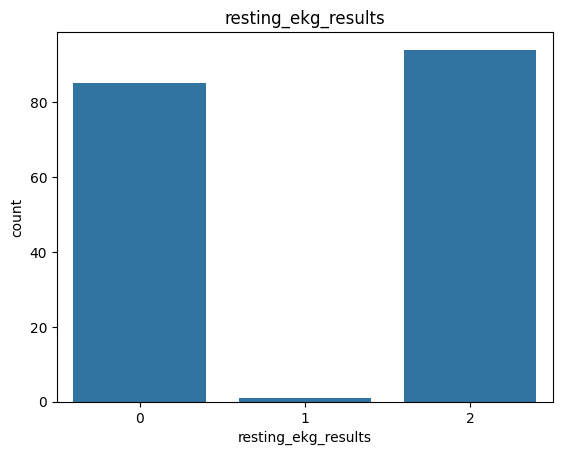

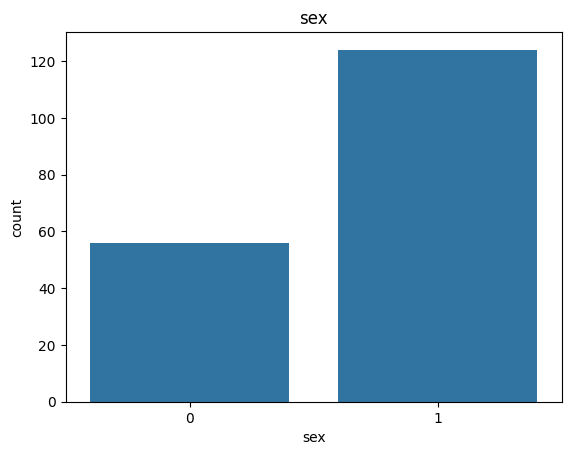

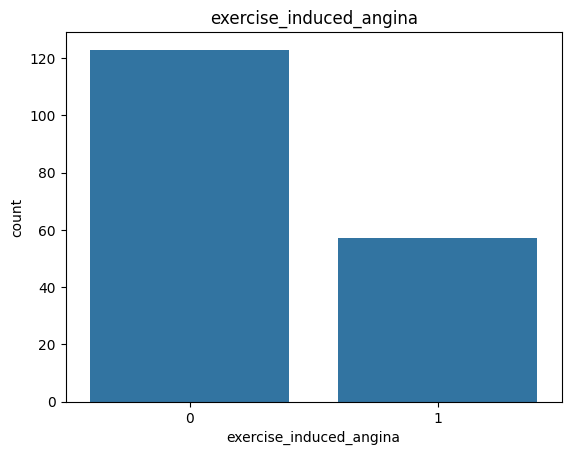

In [17]:


cat_cols = ['thal','chest_pain_type','resting_ekg_results','sex','exercise_induced_angina']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

- Bar charts were plotted for all categorical features in the dataset, resulting in 5 graphs.
- These visualizations help in understanding the frequency distribution of categories such as chest pain type, thal, sex, and other categorical variables. 
- It provides clear insight into the most common categories in the dataset.

### Bivariate Analysis

#### Age vs Heart Disease

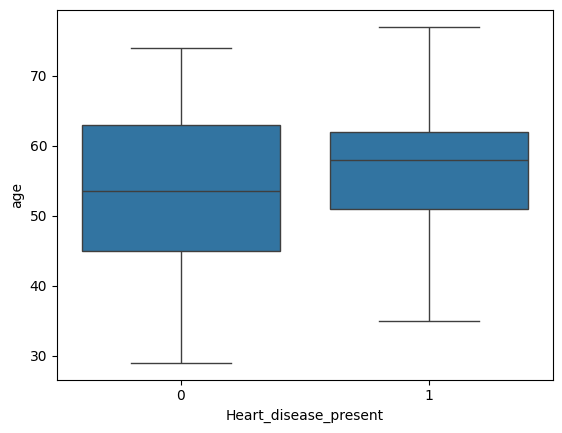

In [18]:
sns.boxplot(x='Heart_disease_present', y='age', data=df)
plt.show()

- Shows how age differs between patients with and without heart disease.
- Helps identify whether age is a risk factor.

#### Chest Pain Type vs Heart Disease

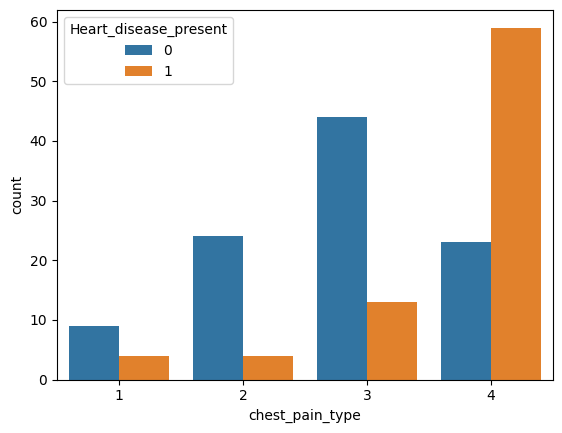

In [19]:
sns.countplot(x='chest_pain_type', hue='Heart_disease_present', data=df)
plt.show()

- This plot shows the relationship between chest pain type and heart disease. 
- It helps identify which chest pain categories are more associated with heart disease cases compared to non-disease cases.

#### Oldpeak vs Heart Disease

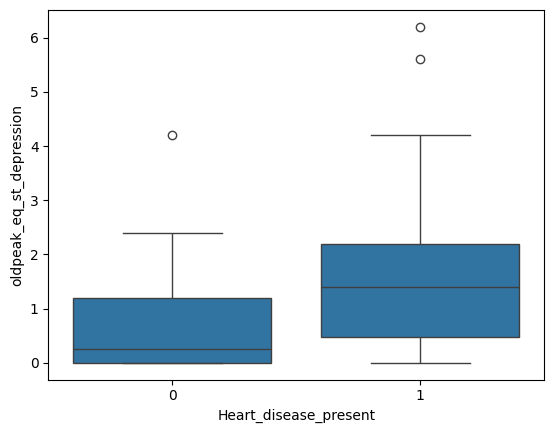

In [20]:
sns.boxplot(x='Heart_disease_present', y='oldpeak_eq_st_depression', data=df)
plt.show()

- This plot compares oldpeak values between patients with and without heart disease. 
- It helps identify whether higher ST depression (oldpeak) is associated with heart disease cases.

#### Max Heart Rate vs Heart Disease

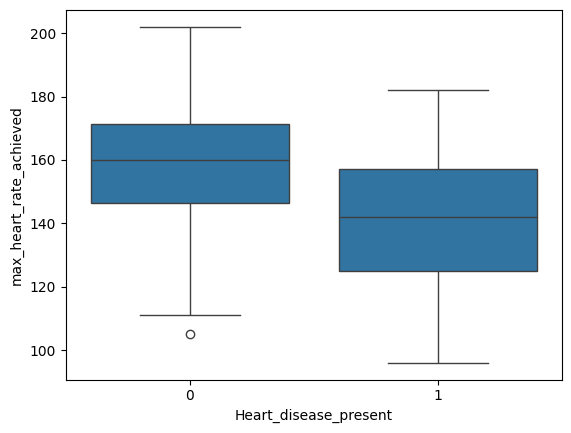

In [21]:
sns.boxplot(x='Heart_disease_present', y='max_heart_rate_achieved', data=df)
plt.show()

- This plot compares maximum heart rate achieved between patients with and without heart disease. 
- It helps identify whether lower or higher heart rate values are associated with heart disease.

#### Exercise Induced Angina vs Heart Disease

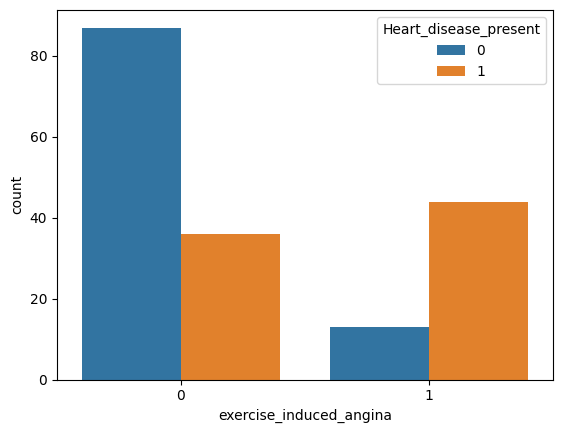

In [22]:
sns.countplot(x='exercise_induced_angina', hue='Heart_disease_present', data=df)
plt.show()

- This plot shows the relationship between exercise-induced angina and heart disease. 
- It helps identify whether patients experiencing angina during exercise are more likely to have heart disease.

### Outlier Analysis

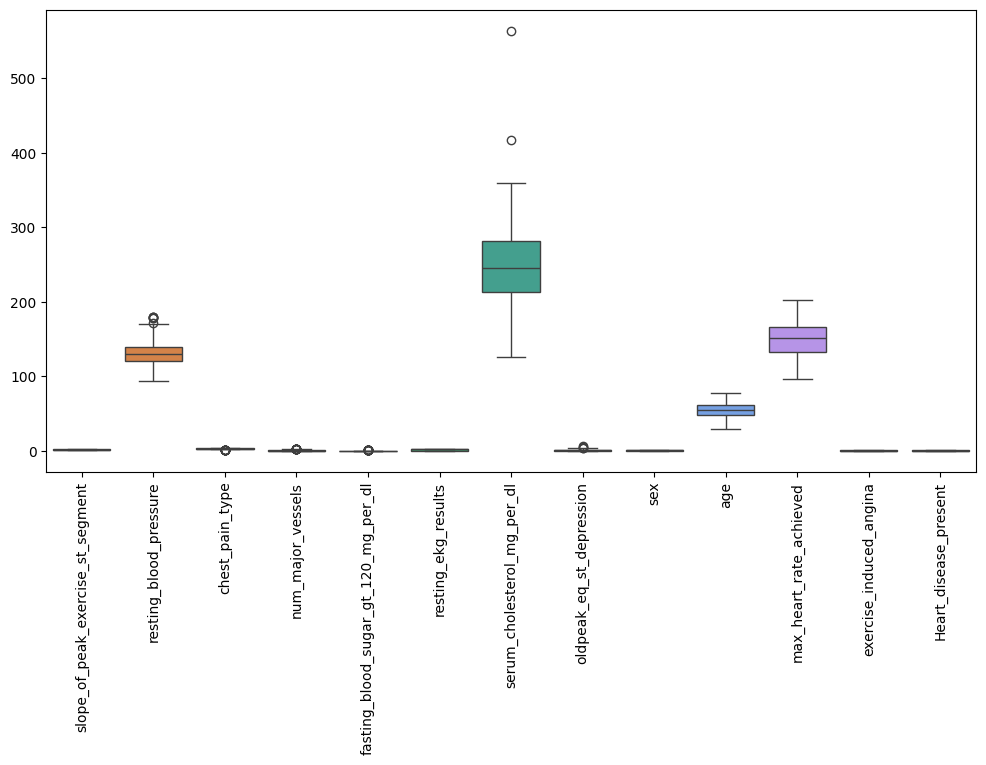

In [23]:


plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

- A box plot was used to visualize the distribution of all numerical features in the dataset.
- It shows that some features such as blood pressure, serum cholesterol, and oldpeak contain extreme values (outliers).
- These values lie outside the whisker range and indicate variability in patient medical conditions.


### Correlation Analysis

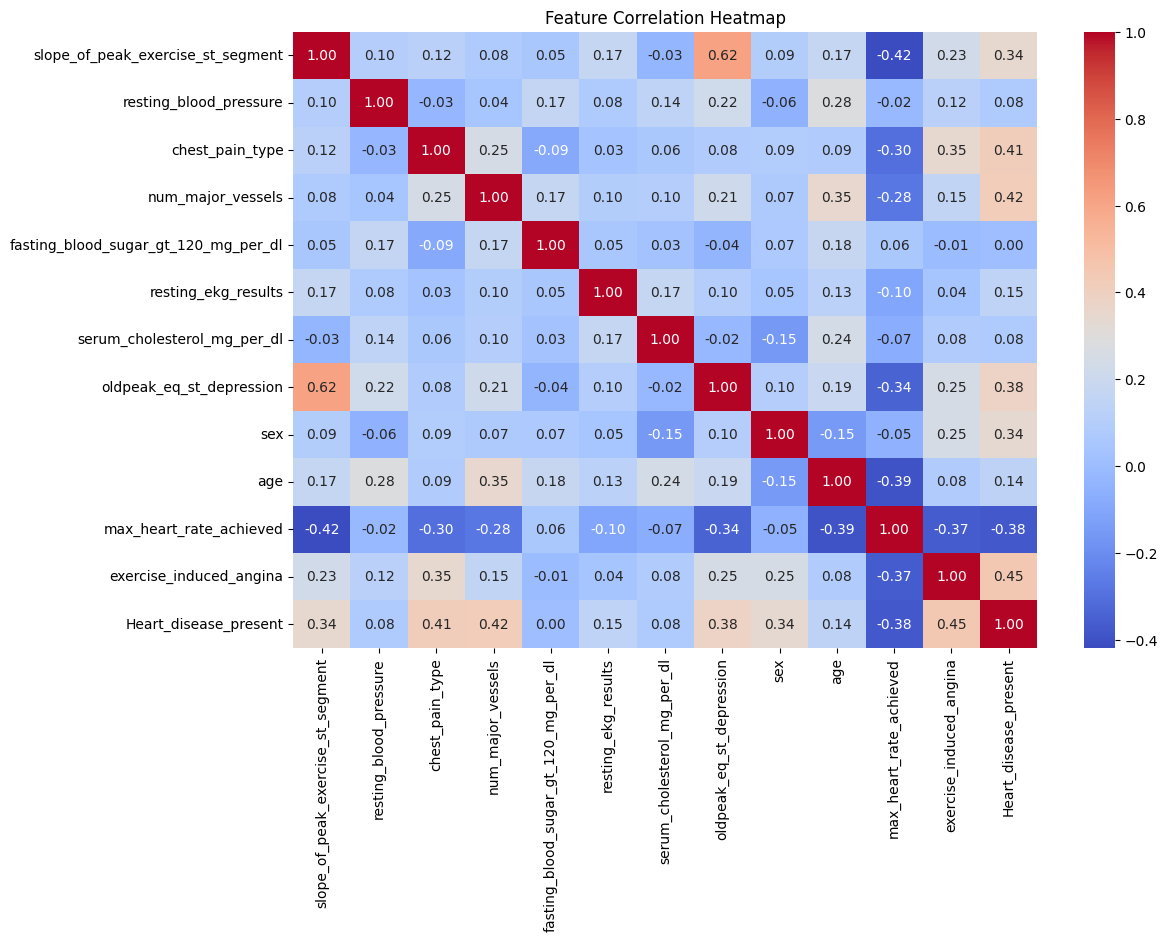

In [24]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

- Correlation heatmap was used to understand relationships between numerical features. 
- It shows how each feature is related to others and to the target variable. 
- Some features show positive or negative correlation with heart disease, indicating their importance in prediction. 
- This helps in selecting relevant features for model building.

### Feature encoding

In [25]:
# Check data types of all columns
df.dtypes

slope_of_peak_exercise_st_segment         int64
thal                                     object
resting_blood_pressure                    int64
chest_pain_type                           int64
num_major_vessels                         int64
fasting_blood_sugar_gt_120_mg_per_dl      int64
resting_ekg_results                       int64
serum_cholesterol_mg_per_dl               int64
oldpeak_eq_st_depression                float64
sex                                       int64
age                                       int64
max_heart_rate_achieved                   int64
exercise_induced_angina                   int64
Heart_disease_present                     int64
dtype: object

No feature encoding was needed as all variables are already numeric.

### Data Preprocessing

In [26]:
#Check categorical columns
df.select_dtypes(include='object').columns

Index(['thal'], dtype='object')

- The dataset contains one categorical feature (thal). 
- This feature was converted into numerical format using Label Encoding so that it can be processed effectively by machine learning algorithms.

In [27]:
#Handling Categorical Variables

le = LabelEncoder()

df['thal'] = le.fit_transform(df['thal'])


The categorical feature thal was converted into numerical values using Label Encoding, enabling machine learning algorithms to process the feature effectively.

In [28]:
#Check the column type after handling
df['thal'].dtype

dtype('int64')

The thal feature was successfully transformed from a categorical data type to an integer (int64) format using Label Encoding, making it suitable for machine learning model training.


#### Feature scaling

In [29]:
scaler = StandardScaler()

X = df.drop('Heart_disease_present', axis=1)

X_scaled = scaler.fit_transform(X)

In [30]:
X_scaled

array([[-0.89124111, -0.64705882, -0.19519463, ..., -1.05396422,
         0.93248505, -0.68074565],
       [ 0.72919727, -0.64705882, -1.25631978, ..., -0.08713407,
         0.38708356, -0.68074565],
       [-0.89124111, -0.64705882, -0.37204882, ...,  2.38365407,
         0.56888406,  1.46897745],
       ...,
       [ 0.72919727,  1.11764706, -0.37204882, ...,  0.98712164,
        -0.8400698 ,  1.46897745],
       [-0.89124111, -0.64705882, -0.43100022, ..., -0.7316875 ,
         1.15973567, -0.68074565],
       [-0.89124111, -0.64705882,  1.69125009, ..., -0.08713407,
         0.61433418, -0.68074565]], shape=(180, 13))

- Feature scaling was successfully applied using StandardScaler.
- The numerical features were transformed to a standardized scale with comparable ranges, helping machine learning algorithms learn more effectively and improving model performance.

#### Split Features & Target

In [31]:
X = df.drop("Heart_disease_present", axis=1)
y = df["Heart_disease_present"]

In [32]:
X.head()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,1,1,128,2,0,0,2,308,0.0,1,45,170,0
1,2,1,110,3,0,0,0,214,1.6,0,54,158,0
2,1,1,125,4,3,0,2,304,0.0,1,77,162,1
3,1,2,152,4,0,0,0,223,0.0,1,40,181,0
4,3,2,178,1,0,0,2,270,4.2,1,59,145,0


In [33]:
y.head()

0    0
1    0
2    1
3    1
4    0
Name: Heart_disease_present, dtype: int64

- X contains all input features, and y contains the target variable (Heart_disease_present). 
- Both are checked to ensure correct separation before model training.

#### Train-Test Split

In [34]:
X = df.drop('Heart_disease_present', axis=1)
y = df['Heart_disease_present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
X_train.shape, X_test.shape

((144, 13), (36, 13))

- A total of 144 records were used for training and 36 records were reserved for testing.
- This ensures that the model can be evaluated on unseen data and helps measure its generalization performance.

In [36]:
y_train.shape, y_test.shape

((144,), (36,))

#### Feature Scaling

In [37]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(144, 13)
(36, 13)


- Feature scaling is applied to normalize all input features into a similar range.
- StandardScaler is used to transform the data so that models like Logistic Regression and SVM perform efficiently.
- Scaling is applied only on training data and then transformed on test data to avoid data leakage.

### Model Building and Evaluation

#### Logistic Regression

In [39]:
#Model training

lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [43]:
#Model Testing
y_pred_lr = lr.predict(X_test)
print(y_pred_lr)

[0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 1 1 0 1 1 1 0]


In [42]:
#Model Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8333333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.88      0.82        16
           1       0.89      0.80      0.84        20

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36


Confusion Matrix:

[[14  2]
 [ 4 16]]


- Logistic Regression (penalty = L2, solver = lbfgs) was trained on training data and tested on unseen data, giving 83% accuracy, which shows a good baseline performance.
- The model performs fairly on both classes, with slightly better results for non-disease prediction.
- A few false negatives are observed, which is important in medical prediction and suggests need for better models or tuning.

#### Random Forest Classifier 

In [45]:
#Model training
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [46]:
#Model Testing
y_pred_rf = rf.predict(X_test)

In [47]:
rf.predict(X_test)

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [48]:
#model Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8055555555555556

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36


Confusion Matrix:

[[15  1]
 [ 6 14]]


- Random Forest Classifier (n_estimators=100, random_state=42) was trained and tested on the heart disease dataset, achieving an accuracy of 81%.
- The model correctly identified most non-disease cases and showed balanced performance across both classes.
- Compared to Logistic Regression (83% accuracy), Random Forest performed slightly lower on this dataset, indicating that Logistic Regression is currently the better model.

#### Support Vector Machine (SVM)

In [50]:


svm = SVC()

svm.fit(X_train, y_train)



,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [51]:
y_pred_svm = svm.predict(X_test)

In [52]:
svm.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [53]:


print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.4722222222222222

Classification Report:

              precision    recall  f1-score   support

           0       0.46      1.00      0.63        16
           1       1.00      0.05      0.10        20

    accuracy                           0.47        36
   macro avg       0.73      0.53      0.36        36
weighted avg       0.76      0.47      0.33        36


Confusion Matrix:

[[16  0]
 [19  1]]


- SVM was trained and tested on the heart disease dataset and achieved an accuracy of 47.22%.
- The model predicted most samples as Class 0, resulting in poor detection of heart disease cases.
- Compared to Logistic Regression and Random Forest, SVM showed significantly lower performance and is not suitable for this dataset with the current parameters.

#### Decision Tree Classifier

In [55]:
#Model Training

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [56]:
#Model testing
y_pred_dt = dt.predict(X_test)

In [57]:
dt.predict(X_test)

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

In [58]:
#Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7777777777777778

Classification Report:

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        16
           1       1.00      0.60      0.75        20

    accuracy                           0.78        36
   macro avg       0.83      0.80      0.78        36
weighted avg       0.85      0.78      0.77        36


Confusion Matrix:

[[16  0]
 [ 8 12]]


- Decision Tree Classifier was trained and tested on the heart disease dataset and achieved an accuracy of 77.78%.
- The model correctly identified all non-disease cases but missed some heart disease cases during prediction.
- Compared with Logistic Regression and Random Forest, Decision Tree showed moderate performance and can be used for model comparison.

#### Model Comparison

In [63]:

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy
0,Logistic Regression,83.33
1,Random Forest,80.56
2,Decision Tree,77.78
3,SVM,47.22


- Four machine learning models were compared based on their prediction accuracy.
- Logistic Regression achieved the highest accuracy (83.33%) among all models.
- Based on the comparison results, Logistic Regression was identified as the best-performing model for heart disease prediction

#### Best Model Selection

- Among all the evaluated models, Logistic Regression achieved the highest accuracy of 83.33%.
- The model demonstrated better overall performance compared to Random Forest, Decision Tree, and SVM.
- Therefore, Logistic Regression was selected as the final model for heart disease prediction.

### Cross Validation

In [64]:
from sklearn.model_selection import cross_val_score


scores = cross_val_score(LogisticRegression(), X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.83333333 0.83333333 0.91666667 0.69444444 0.91666667]
Average Score: 0.8388888888888889


- Cross validation was performed using 5-fold validation to assess the model's consistency across different data splits.
- The model achieved an average cross-validation score of 83.89%, indicating reliable performance

#### Overfitting and Underfitting Analysis

In [65]:
train_accuracy = lr.score(X_train, y_train)
test_accuracy = lr.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8611111111111112
Testing Accuracy: 0.8333333333333334


- The training accuracy (86.11%) and testing accuracy (83.33%) are very close to each other.
- The small difference between the two scores indicates that the model generalizes well to unseen data.
- Therefore, the Logistic Regression model is well-fitted and shows no significant signs of overfitting or underfitting.

#### Hyperparameter Tuning Using GridSearchCV 

In [68]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Best Parameters: {'C': 1}
Best Cross Validation Score: 0.8541871921182265


##### Tuned Model Evaluation

In [67]:
from sklearn.metrics import accuracy_score

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.8333333333333334


- Hyperparameter tuning was performed using GridSearchCV to optimize the Logistic Regression model.
- The best parameter identified was C = 1, achieving a cross-validation score of 85.42%.
- The tuned model achieved an accuracy of 83.33%, which is the same as the baseline model, indicating that the original Logistic Regression model was already well-optimized.

##### Performance After Hyperparameter Tuning

- Hyperparameter tuning did not improve the test accuracy beyond the baseline model.
- This suggests that the default Logistic Regression configuration was already suitable for the dataset.
- Therefore, Logistic Regression remains the final selected model for heart disease prediction.

#### Recommendations to the Hospital for Heart Disease Prevention

- Perform regular heart disease screening for patients.
- Keep track of patients with diabetes, high BP, and cholesterol issues.
- Use ML model as a support tool for early prediction.
- Encourage healthy lifestyle habits like exercise and proper diet.
- Increase awareness about heart disease risk factors.
- Follow-up regularly with high-risk patients

#### Challenges Faced During the Project
- Understanding medical attributes and interpreting their importance in the dataset.
- Handling missing values, encoding categorical features, and preparing data for modeling.
- Comparing multiple machine learning models and analyzing their performance differences.
- Evaluating models using metrics like accuracy, precision, recall, and F1-score.
- Performing hyperparameter tuning, but observing only minimal improvement in performance.

### Conclusion of the Project
- A heart disease prediction system was developed using machine learning techniques.
- The dataset was carefully analyzed and preprocessed for model building.
- Multiple classification models were trained and evaluated.
- Logistic Regression showed strong performance and was selected as the final model.
- Hyperparameter tuning did not lead to significant improvement in accuracy.
- The developed model can help in early detection of heart disease and support clinical decision-making.